In [3]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")
demo_data['years_experience'] = demo_data['semesters_experience'] / 2
demo_data = demo_data.set_index('id')
print(demo_data[['age', 'GPA', 'years_experience']].describe())

             age        GPA  years_experience
count  28.000000  27.000000         28.000000
mean   21.035714   3.414074          2.589286
std     1.731669   0.334103          1.000496
min    19.000000   2.500000          1.000000
25%    20.000000   3.300000          2.000000
50%    21.000000   3.430000          2.500000
75%    22.000000   3.600000          3.000000
max    25.000000   4.000000          5.000000


In [5]:
from scipy import stats

def find_cutoff(vec, threshold=10**4):
    copy = vec.copy()
    copy.sort()
    return copy[-threshold - 1]

best_models = ['code-deepseek_6b-ndelays_4-look_ahead_by_10',
               'code-codegemma_7b-ndelays_4-look_ahead_by_10',
               'code-codegemma_7b-ndelays_16-look_ahead_by_0',
               'prose-codegemma_7b-ndelays_10-look_ahead_by_5',
               'prose-deepseek_6b-ndelays_20-look_ahead_by_10']

participant_base_path = "/data/zachkaras/fmri_model_data/ridge_regression_pca_params"
participants = os.listdir(participant_base_path)

# participant_means[model][layer_num][participant_id] = mean z-scored correlation
participant_means = {}

for m in best_models:
    parts = m.split('-')
    task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]
    participant_means[m] = {}

    for p in participants:
        files = os.listdir(f"{participant_base_path}/{p}")
        pattern = f"{model}-{task}-{look_ahead}-{delays}"
        best_files = [f for f in files if re.search(pattern, f) and f.endswith('correlations.pkl')]

        for bf in best_files:
            layer_num = int(re.search(r'layer_(\d+)', bf).group(1))
            if layer_num not in participant_means[m]:
                participant_means[m][layer_num] = {}

            with open(f"{participant_base_path}/{p}/{bf}", 'rb') as f:
                corrs = pickle.load(f)

            z = np.arctanh(corrs)
            cutoff = find_cutoff(z)
            top_vals = z[np.where(z > cutoff)[0]]
            participant_means[m][layer_num][int(p)] = float(np.mean(top_vals))

print("Done. Models:", list(participant_means.keys()))

Done. Models: ['code-deepseek_6b-ndelays_4-look_ahead_by_10', 'code-codegemma_7b-ndelays_4-look_ahead_by_10', 'code-codegemma_7b-ndelays_16-look_ahead_by_0', 'prose-codegemma_7b-ndelays_10-look_ahead_by_5', 'prose-deepseek_6b-ndelays_20-look_ahead_by_10']


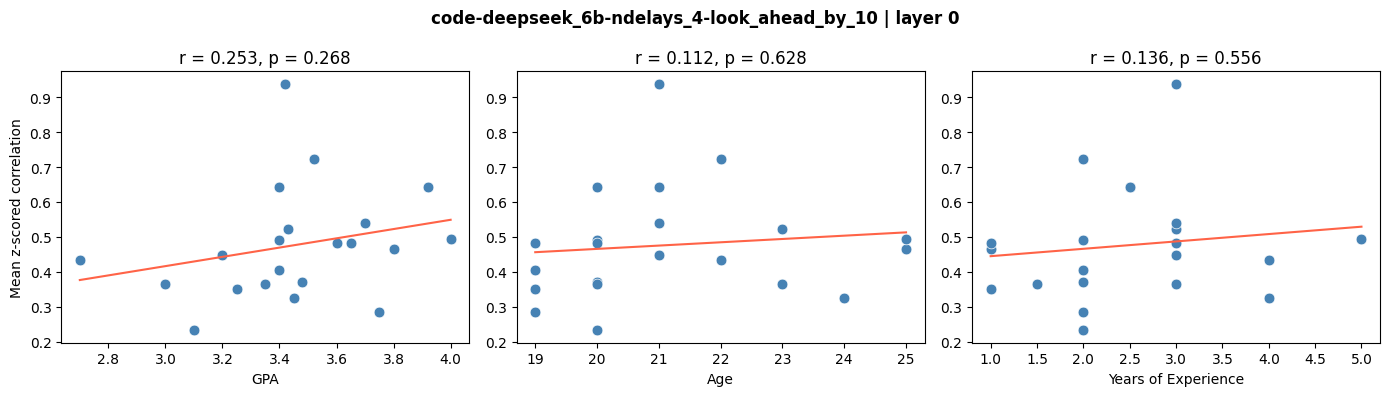

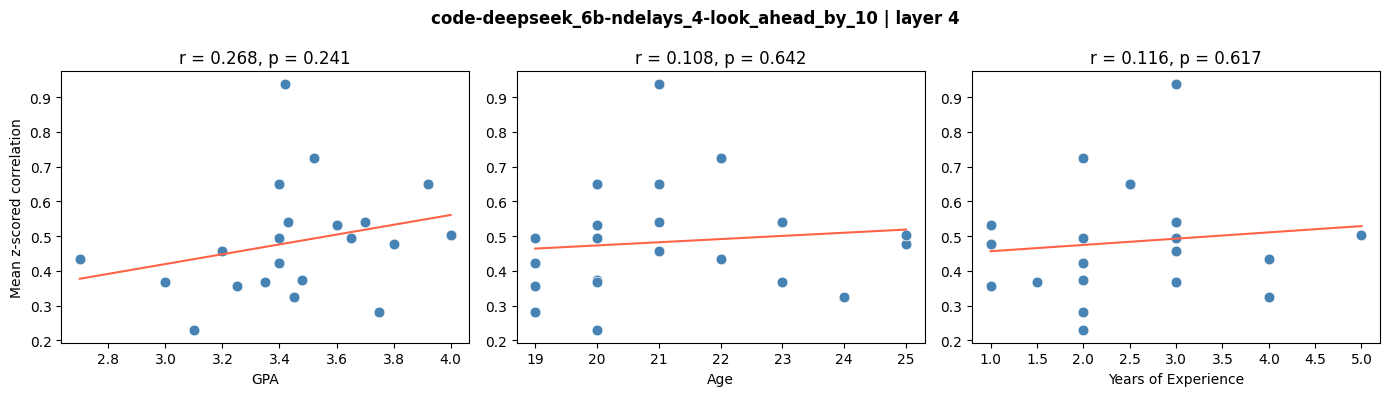

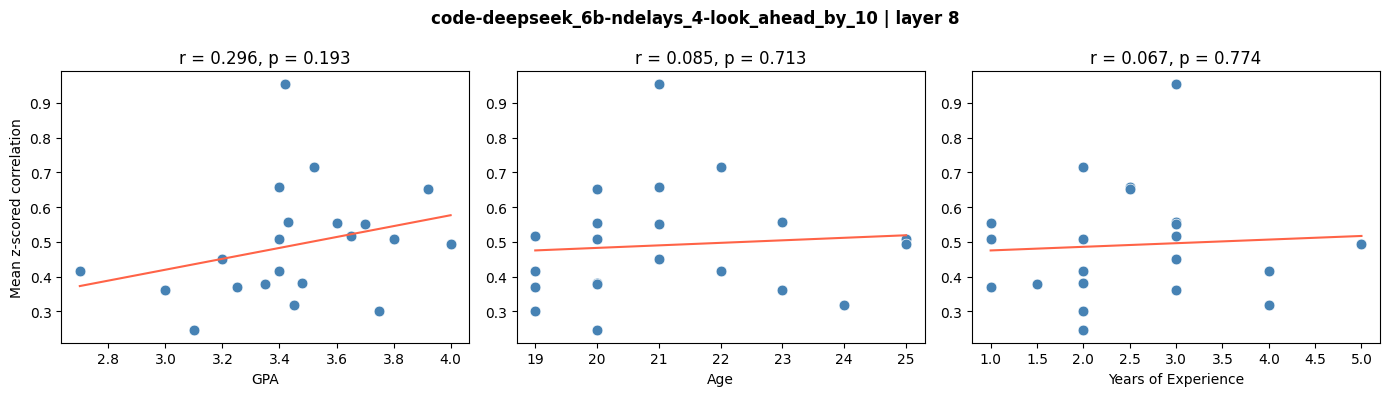

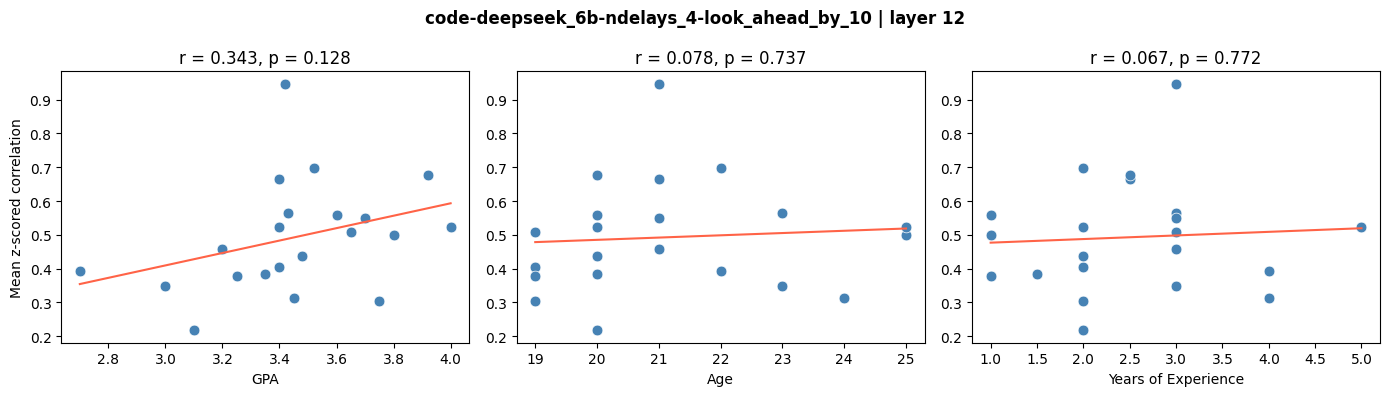

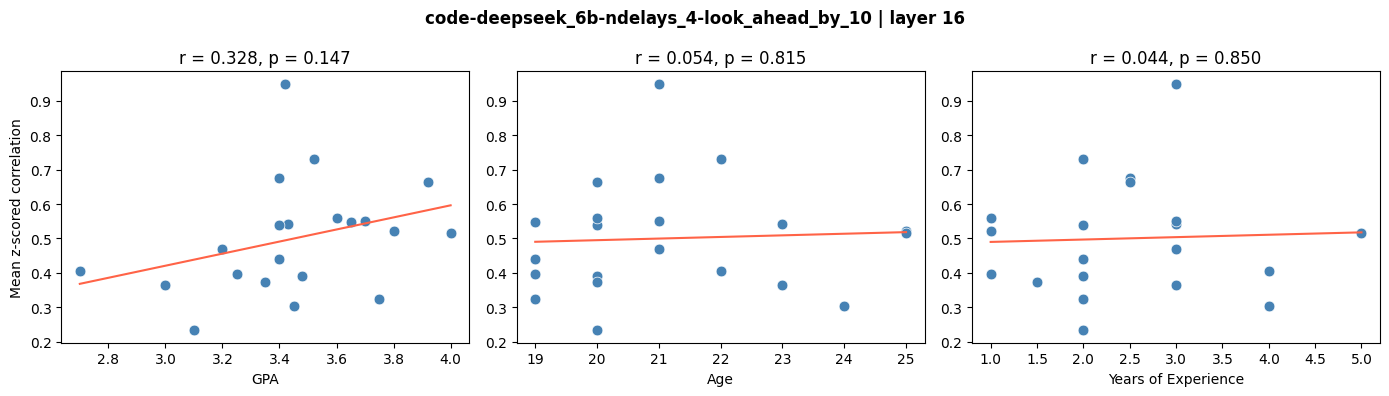

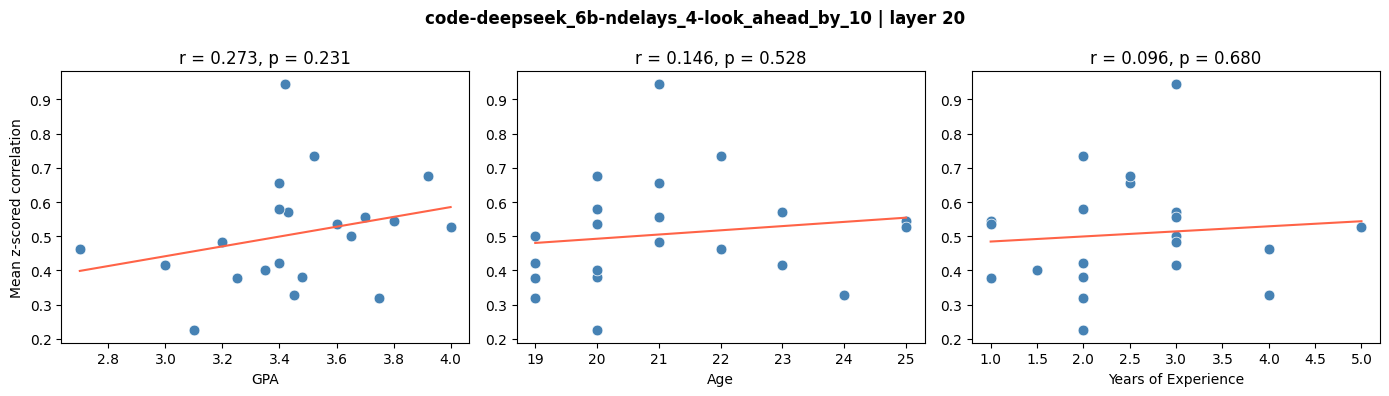

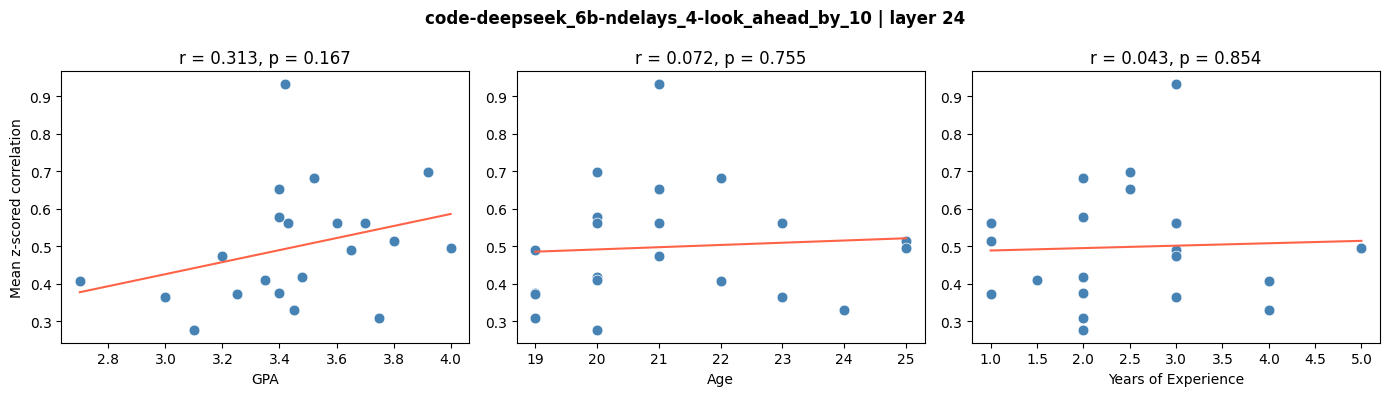

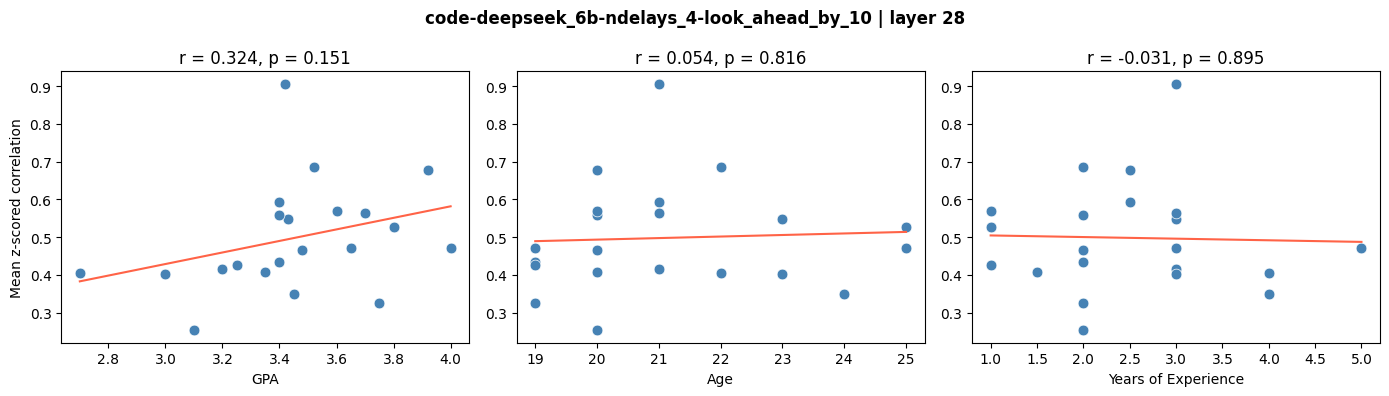

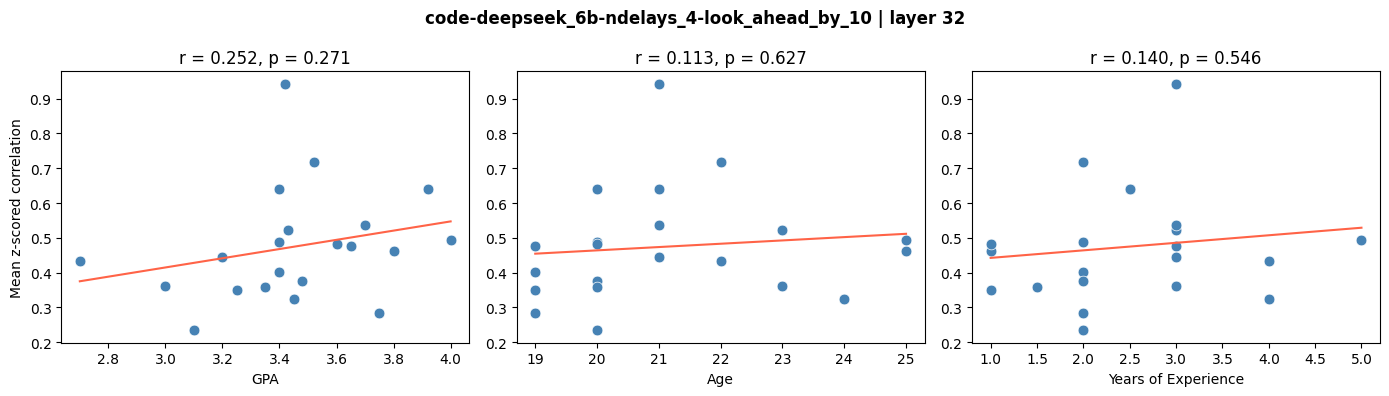

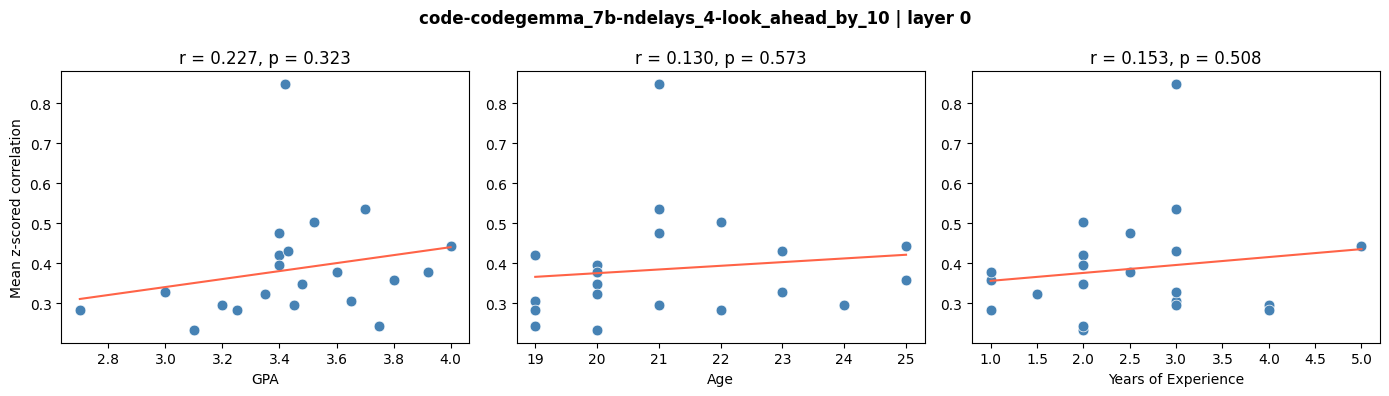

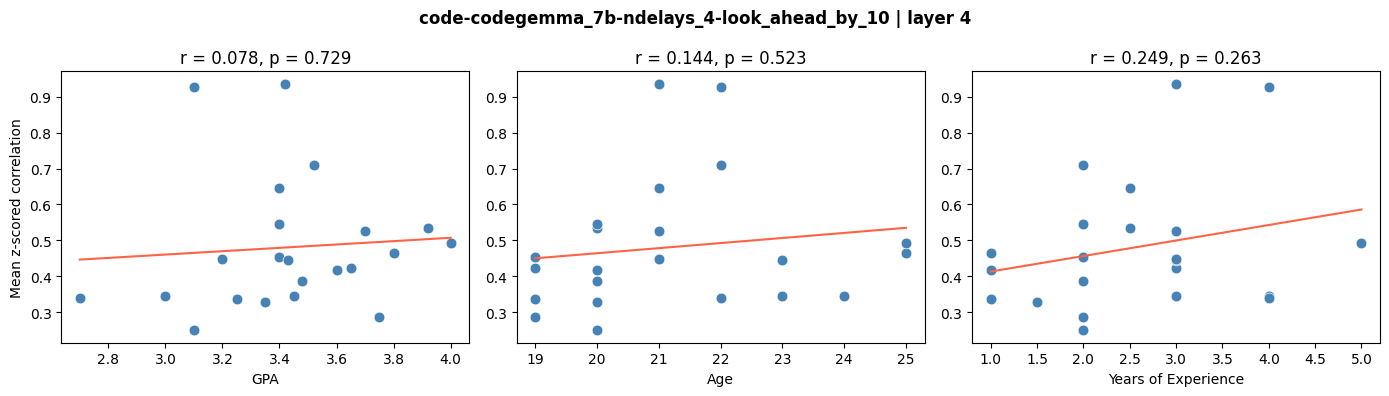

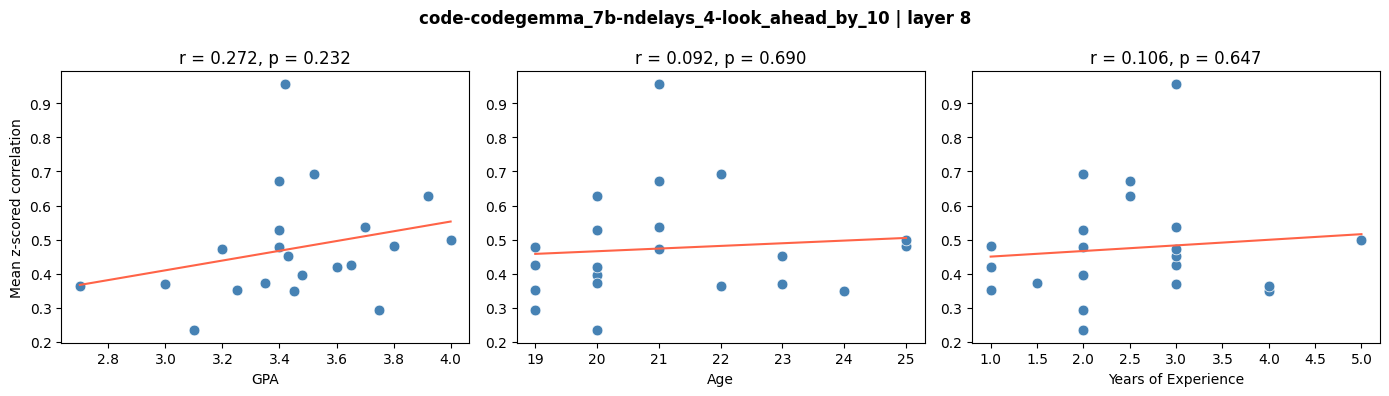

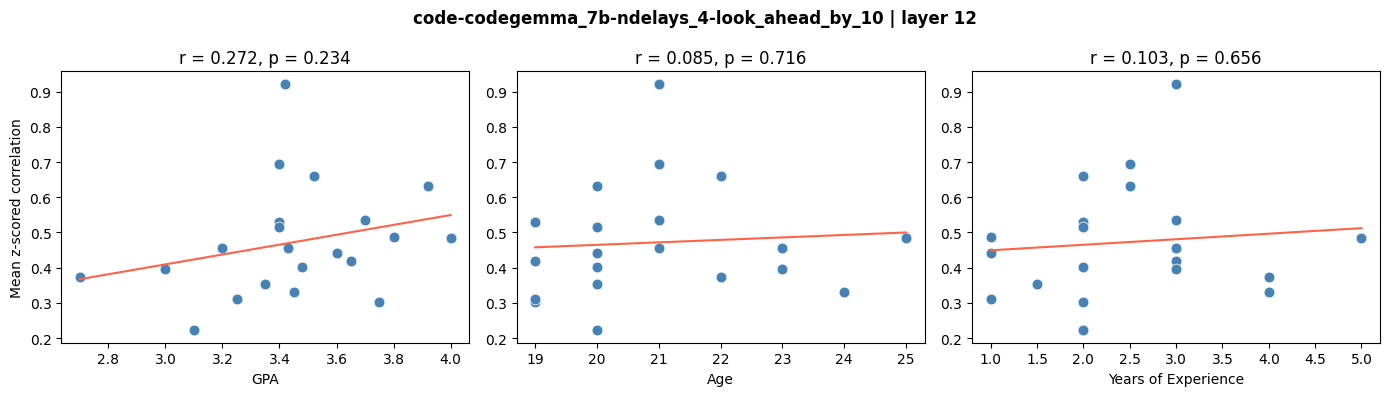

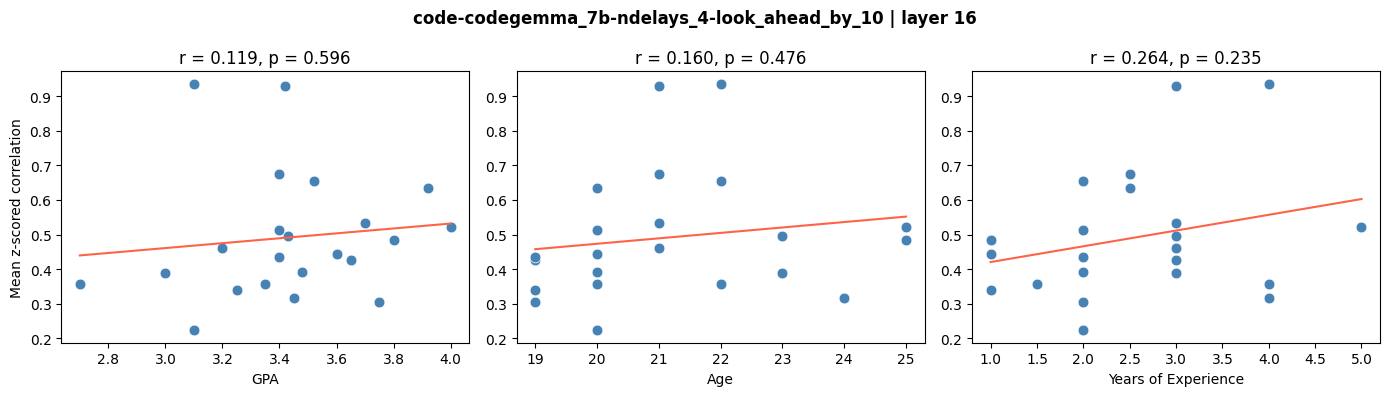

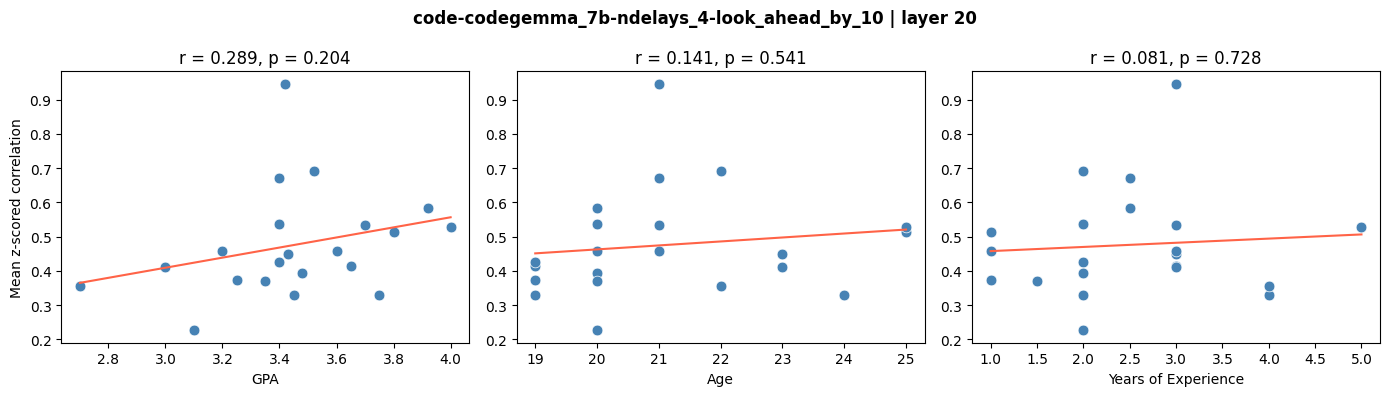

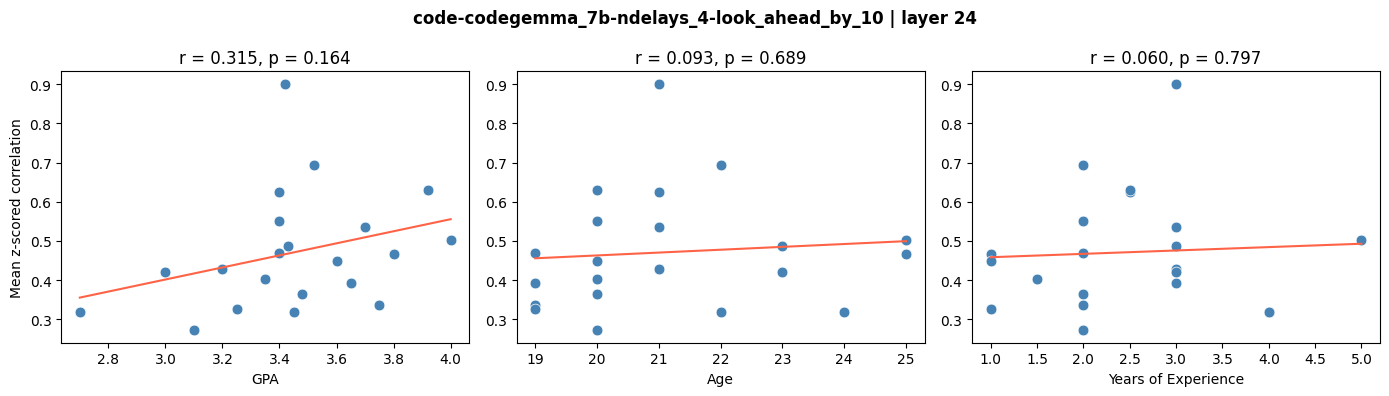

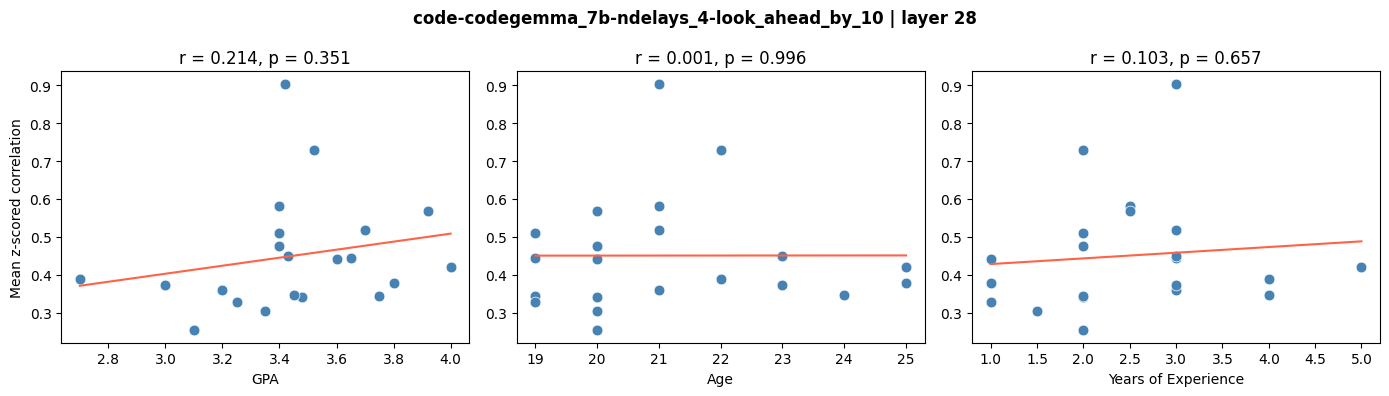

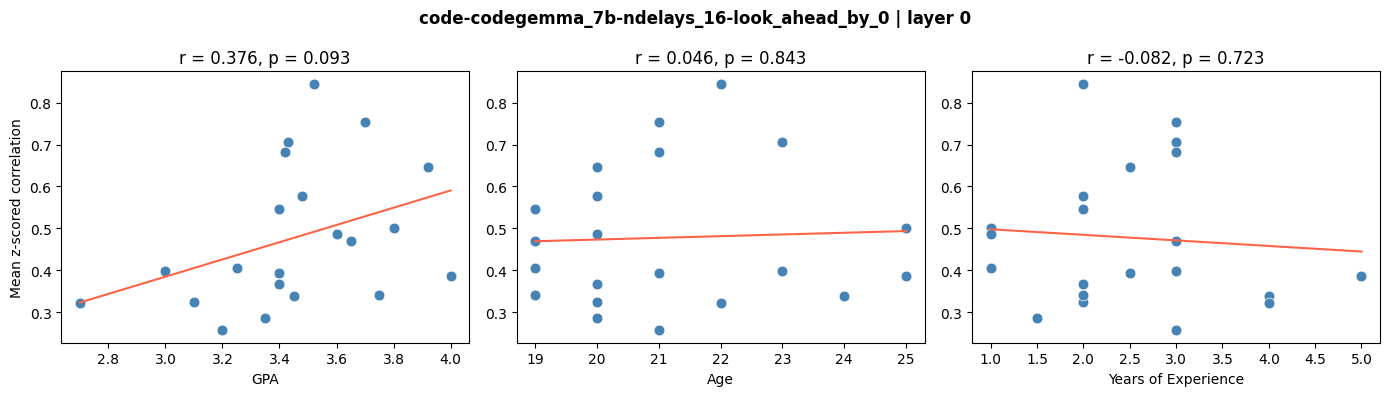

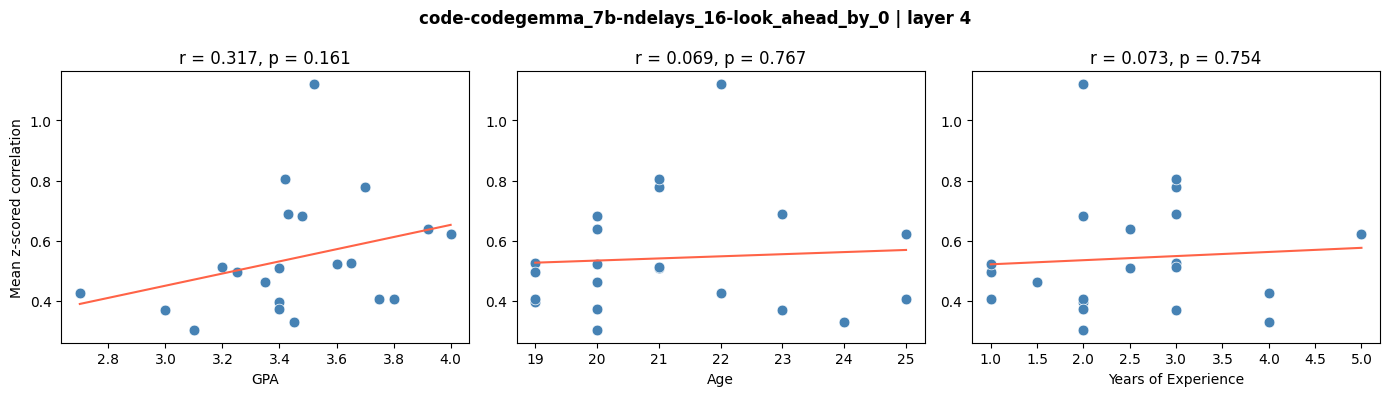

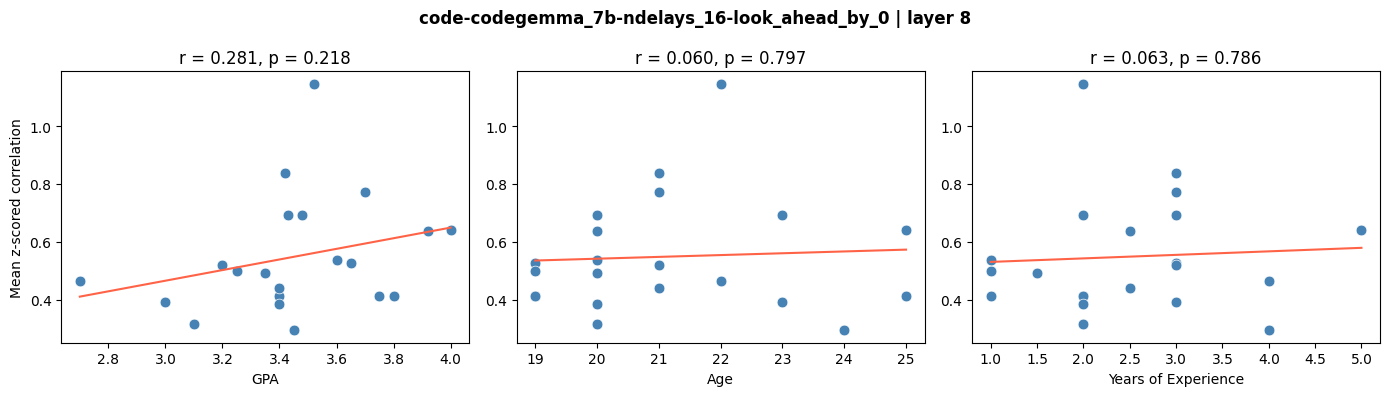

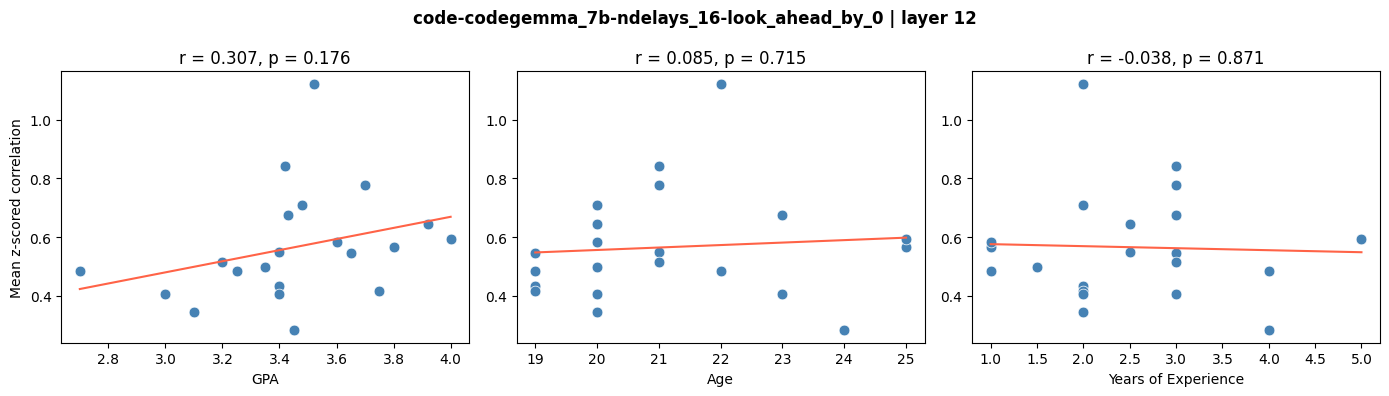

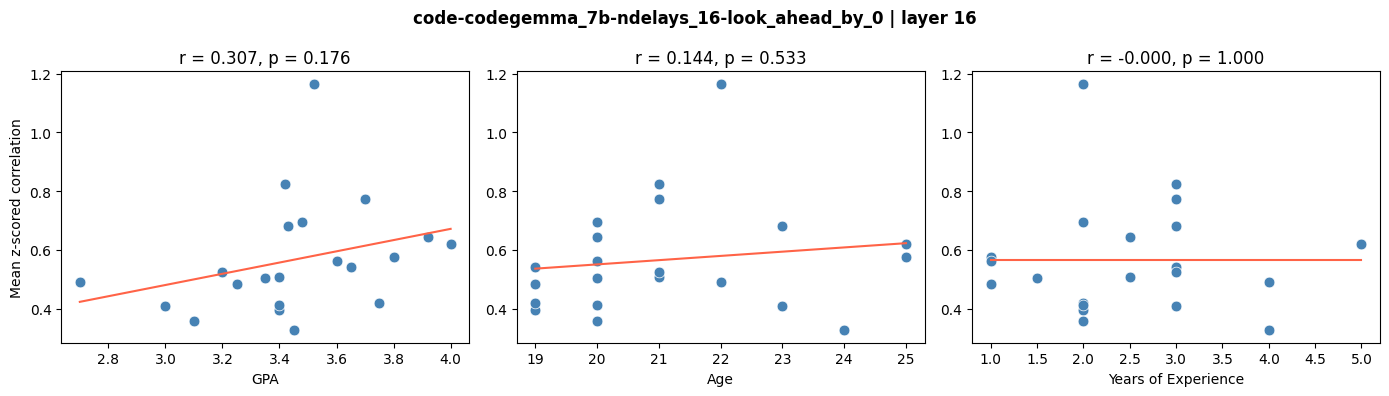

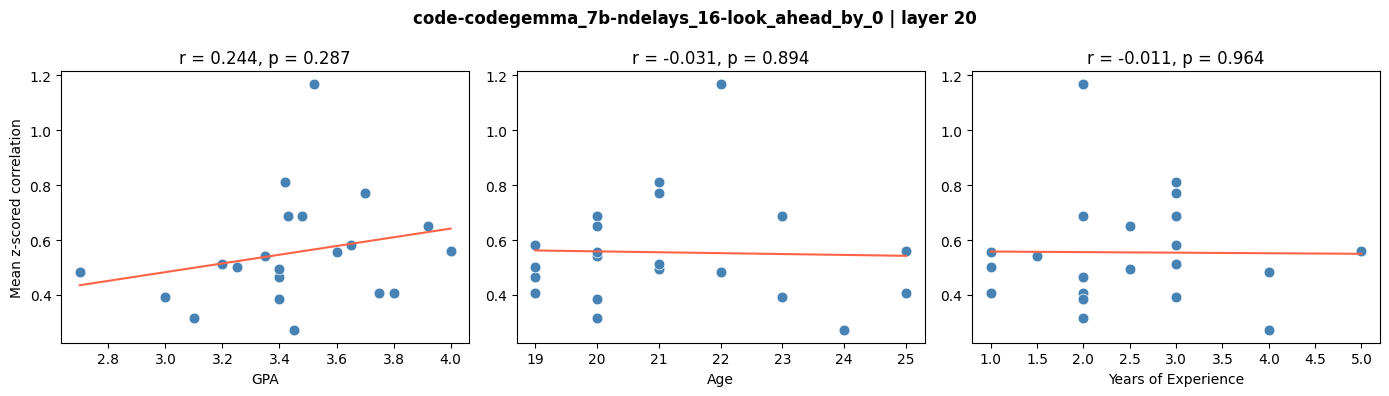

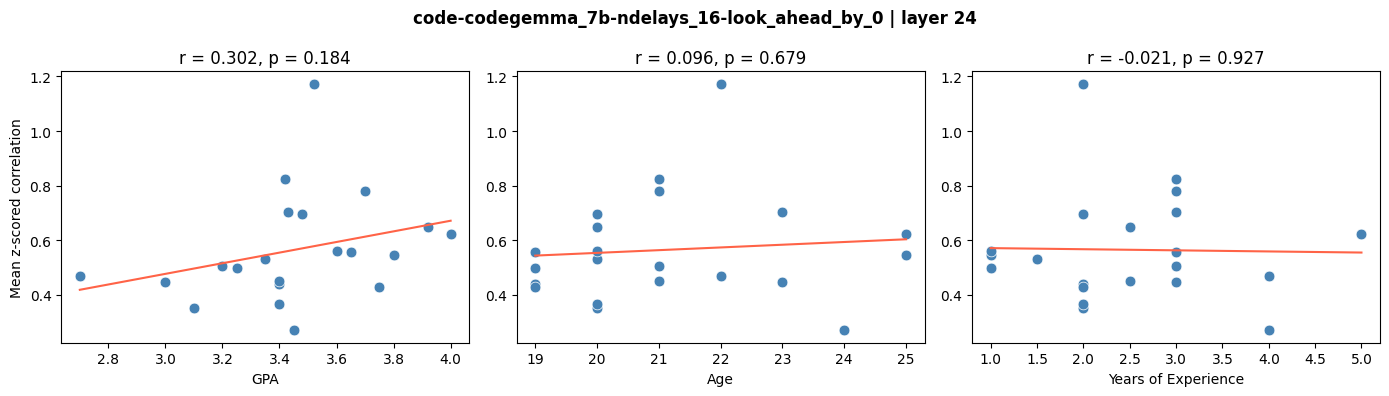

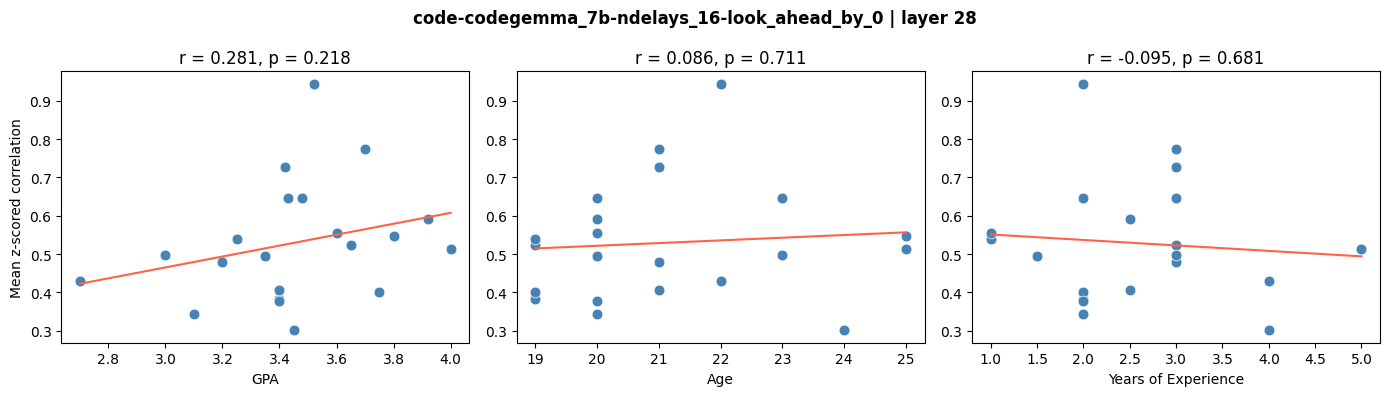

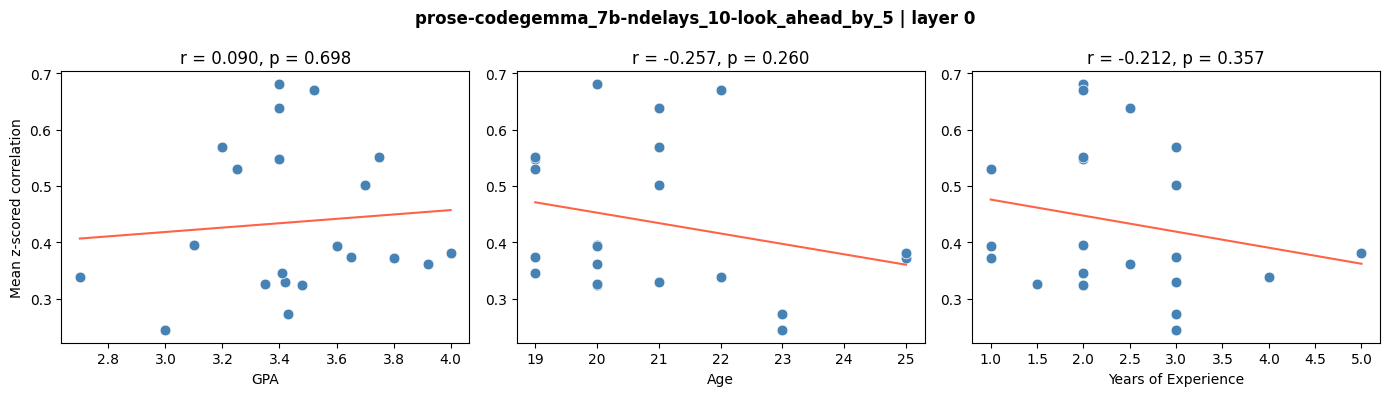

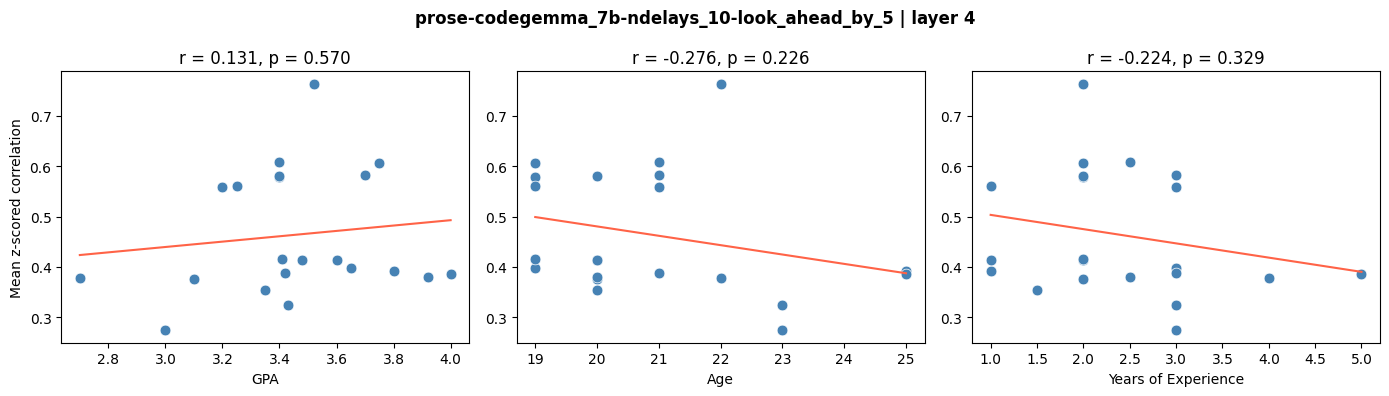

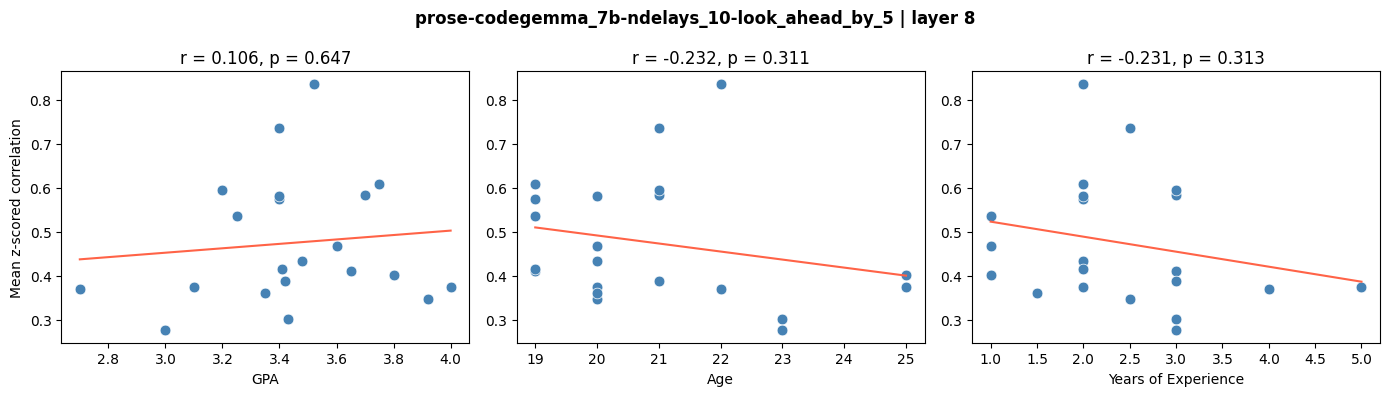

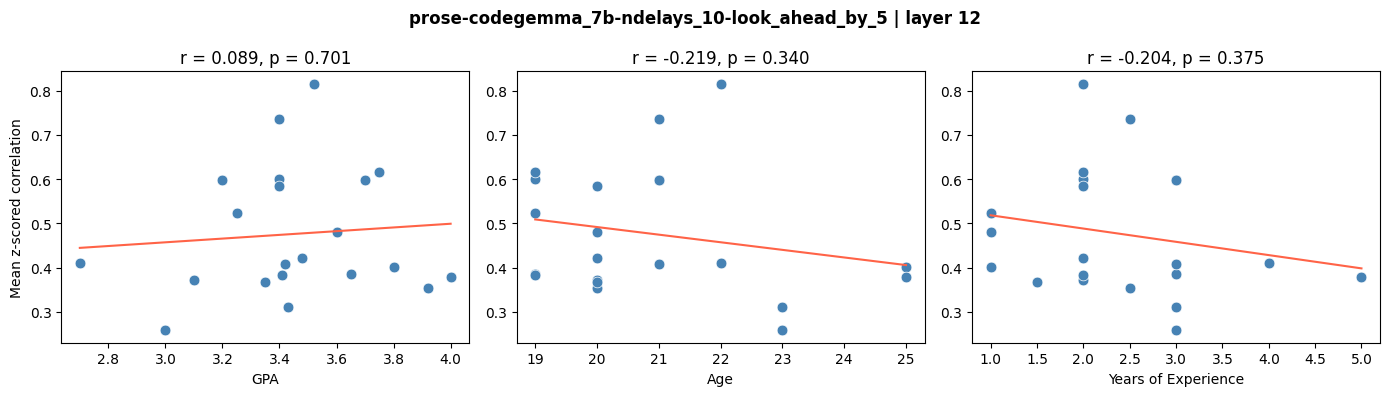

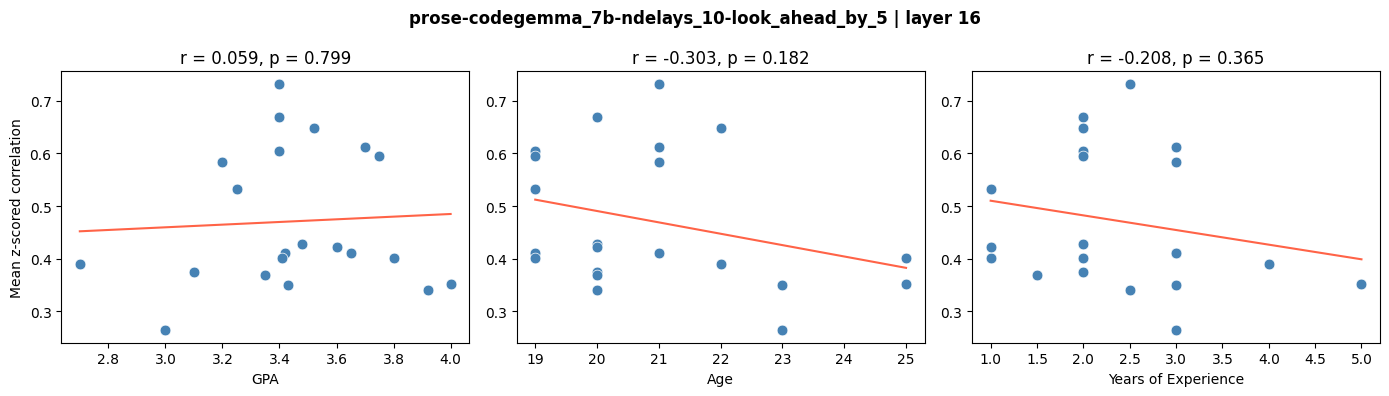

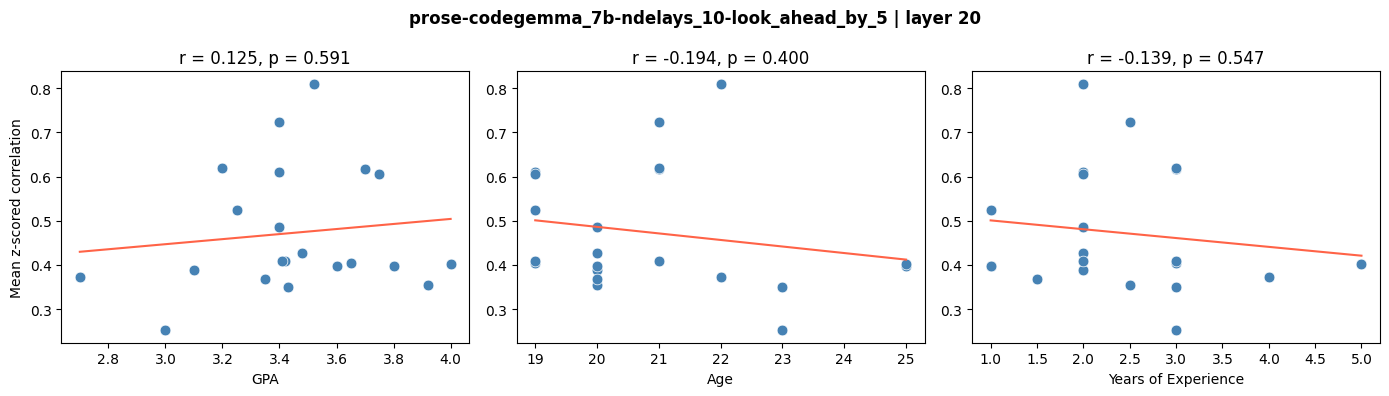

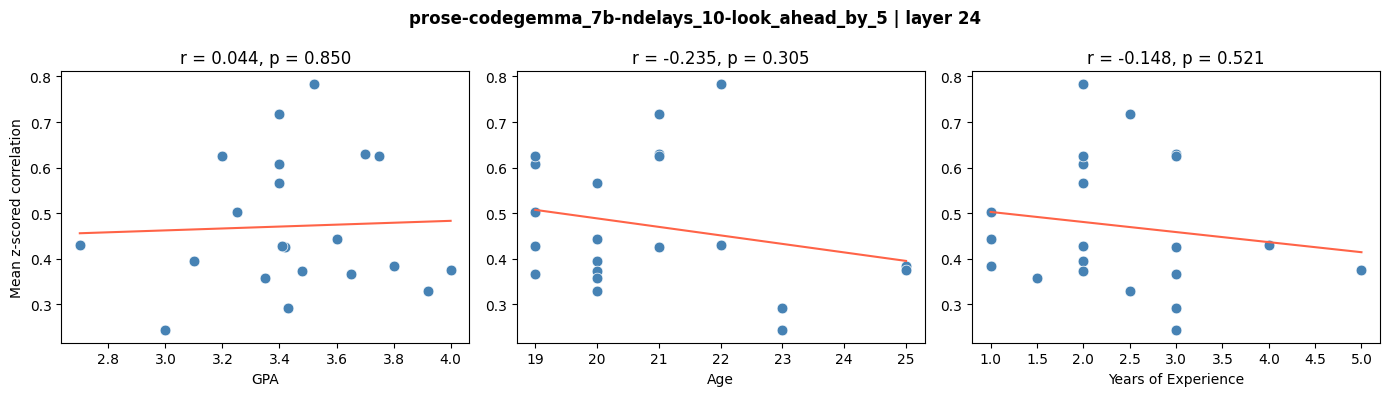

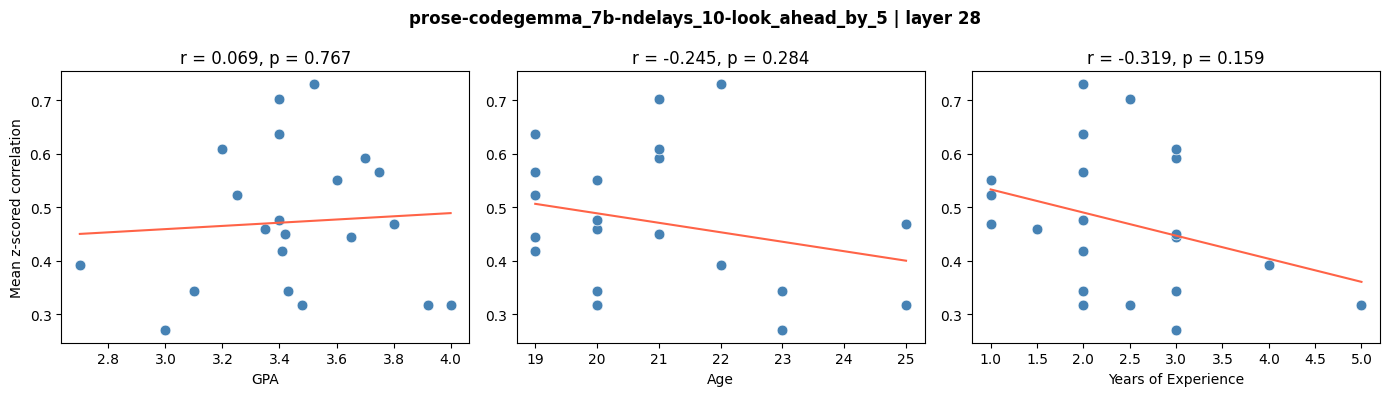

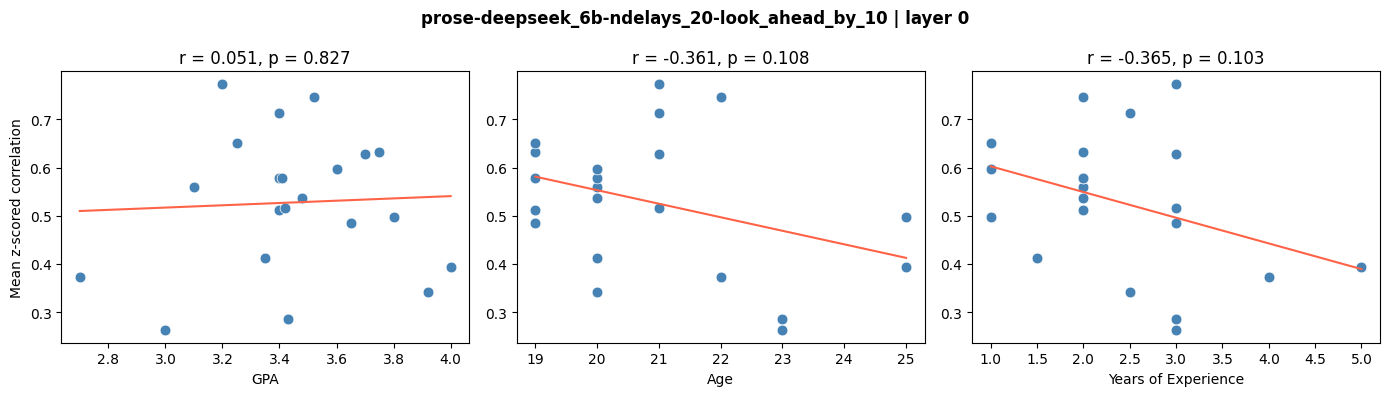

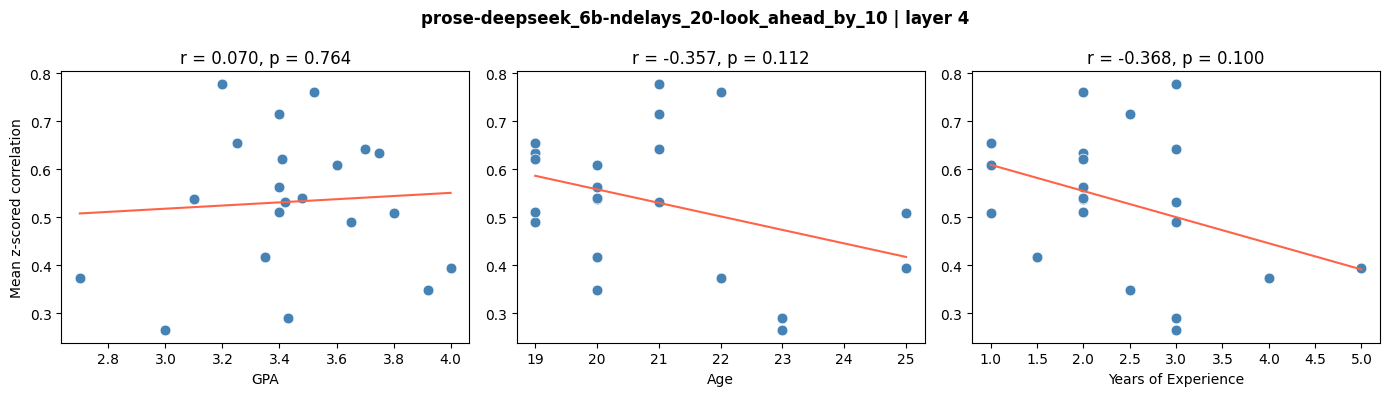

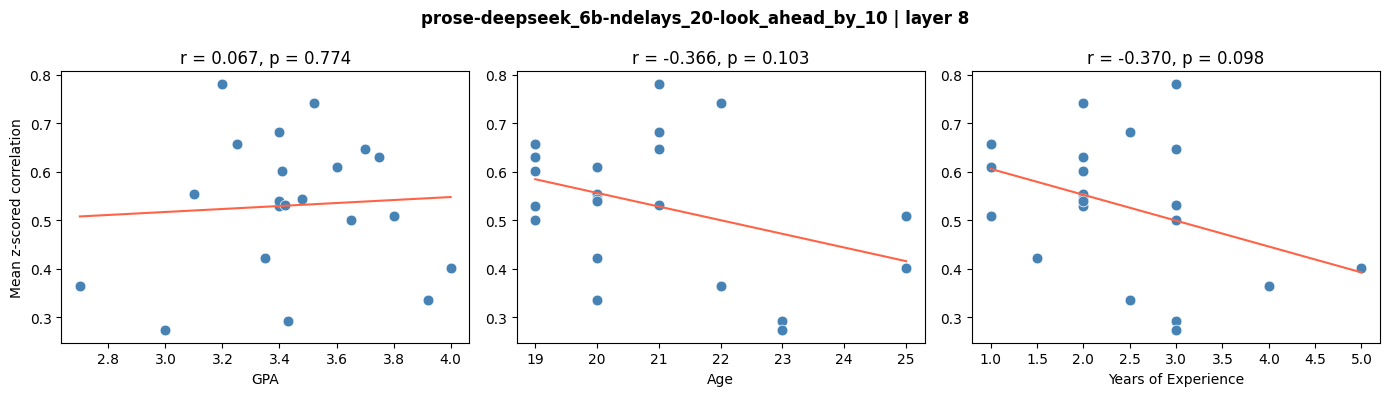

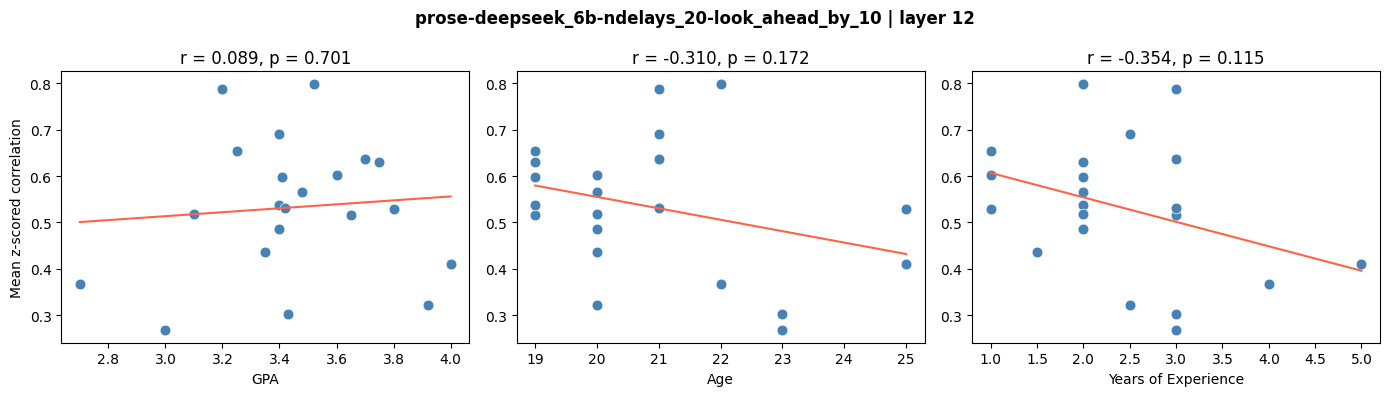

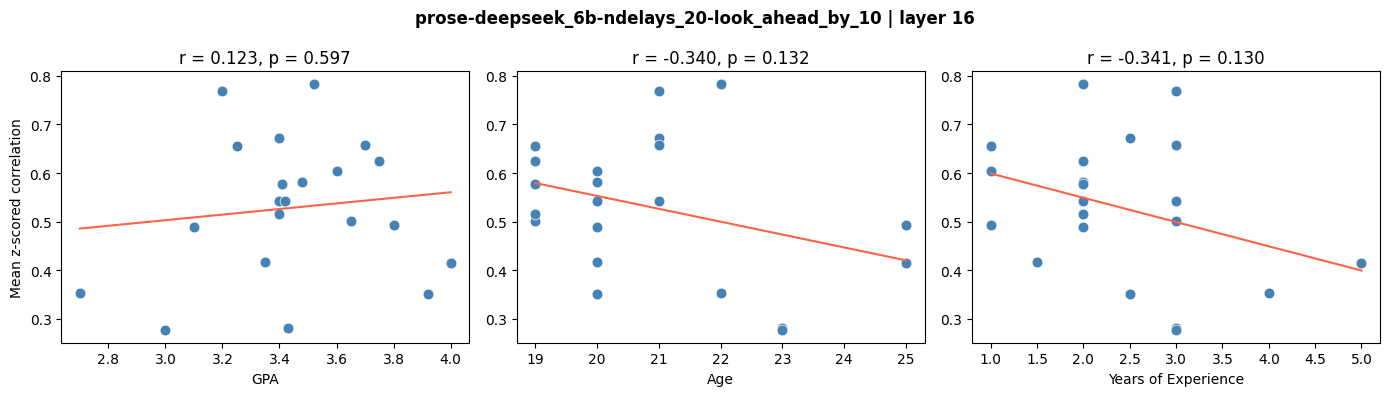

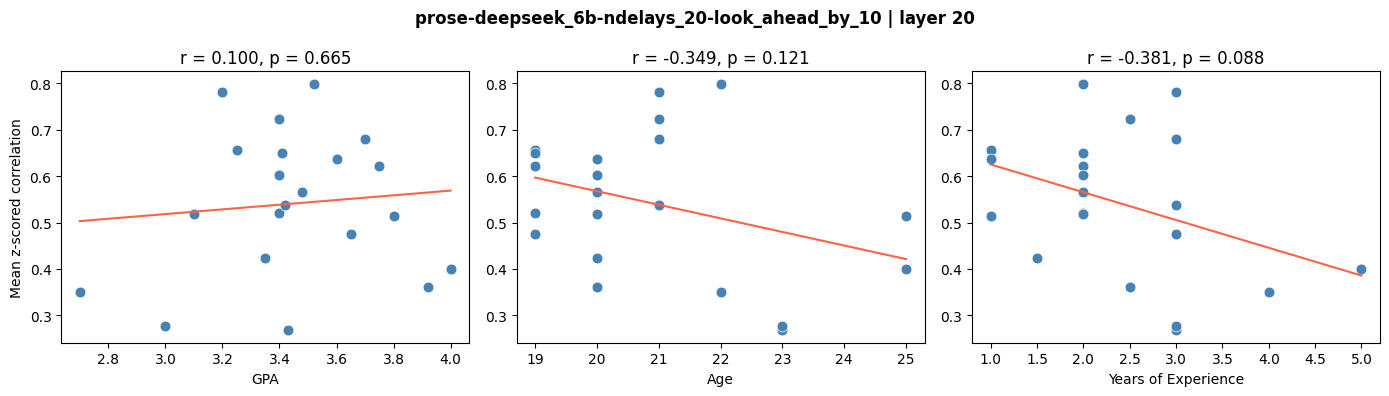

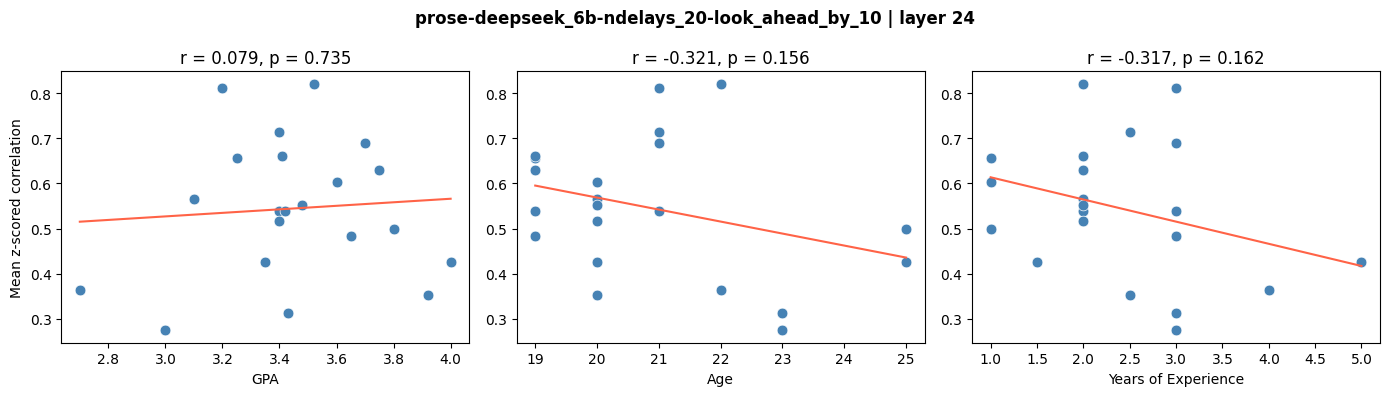

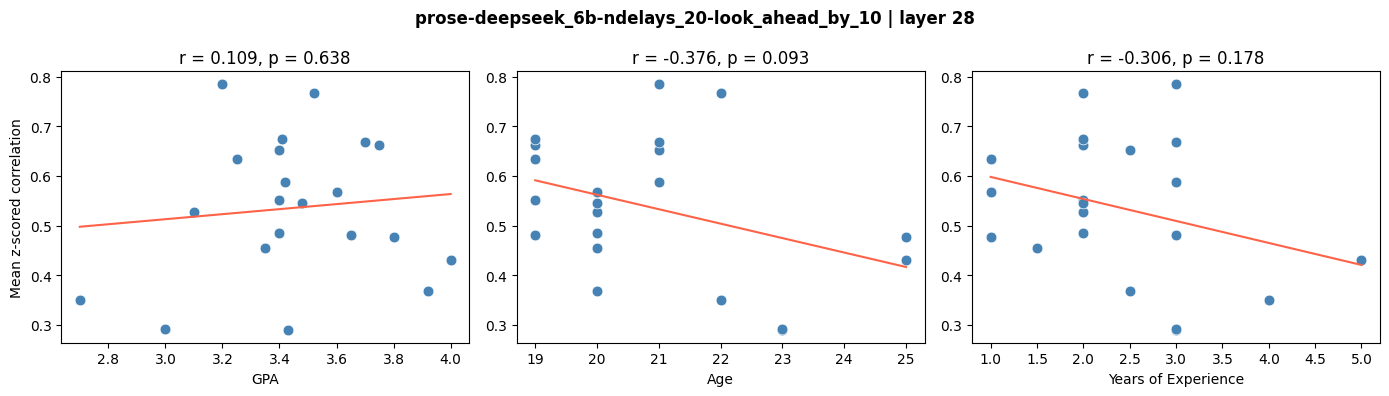

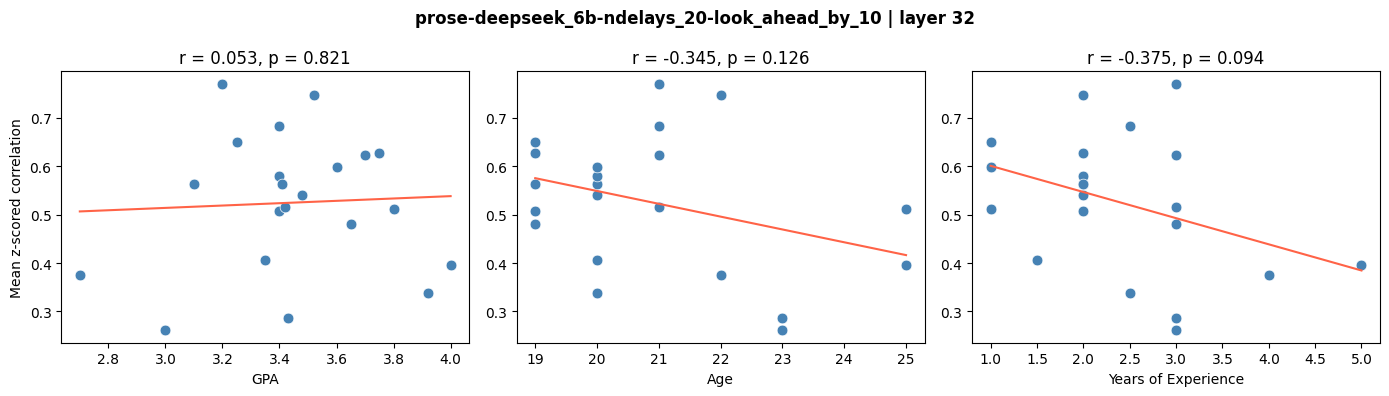

In [6]:
variables = {
    'GPA': 'GPA',
    'Age': 'age',
    'Years of Experience': 'years_experience',
}

for m in best_models:
    layers = sorted(participant_means[m].keys())
    for layer_num in layers:
        layer_data = participant_means[m][layer_num]

        # align participants present in both the fMRI data and demo data
        common_ids = [pid for pid in layer_data if pid in demo_data.index]
        brain_vals = np.array([layer_data[pid] for pid in common_ids])

        fig, axes = plt.subplots(1, len(variables), figsize=(14, 4))
        fig.suptitle(f"{m} | layer {layer_num}", fontsize=12, fontweight='bold')

        for ax, (var_label, col) in zip(axes, variables.items()):
            demo_vals = demo_data.loc[common_ids, col].values.astype(float)

            # drop any NaNs
            mask = ~np.isnan(demo_vals)
            x, y = demo_vals[mask], brain_vals[mask]

            r, p = stats.pearsonr(x, y)

            ax.scatter(x, y, color='steelblue', edgecolors='white', linewidths=0.5, s=60)

            # regression line
            m_fit, b_fit = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, m_fit * x_line + b_fit, color='tomato', linewidth=1.5)

            ax.set_xlabel(var_label)
            ax.set_ylabel('Mean z-scored correlation' if ax == axes[0] else '')
            ax.set_title(f"r = {r:.3f}, p = {p:.3f}")

        plt.tight_layout()
        plt.savefig(f"results/corr_{m}_layer{layer_num}.png", dpi=150, bbox_inches='tight')
        plt.show()

In [ ]:
# TODO - compute variables of interest based on keystroke behavior